<a href="https://colab.research.google.com/github/NavyaSri011/NavyaSriUlli_Task_and_Assment_IN226061402_Innomatics/blob/main/Task_4_Fine_Tuning_BERT_on_Kaggle_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ASSIGNMENT NLP – 4 (BERT Fine-Tuning)
Assignment: Fine-Tuning BERT on a Kaggle Dataset

Objective
Learn BERT fine-tuning, use transformer pipelines, perform experiments, and evaluate model performance using multiple metrics.


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset.csv


STEP 1 — Install Required Libraries

In [ ]:
!pip install transformers datasets accelerate evaluate scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.7 MB/s eta 0:00:00


STEP 2 — Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

from datasets import Dataset
import matplotlib.pyplot as plt
import seaborn as sns

STEP 3 — Load Dataset

In [ ]:
df = pd.read_csv("IMDB Dataset.csv")

STEP 4 — Data Preprocessing

In [ ]:
# Check first rows
df.head()
# Check missing values
df.isnull().sum()
# Remove missing values
df.dropna(inplace=True)
# Convert labels into numbers
df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})
# Keep dataset smaller for faster training
# You can increase later if needed
df = df.sample(3000, random_state=42)

STEP 5 — Train Validation Test Split

In [ ]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['review'],
    df['sentiment'],
    test_size=0.3,
    random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    random_state=42
)

STEP 6 — Load Tokenizer

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

STEP 7 — Tokenization

In [ ]:
def tokenize_function(texts):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=256
    )
train_encodings = tokenize_function(train_texts.tolist())
val_encodings = tokenize_function(val_texts.tolist())
test_encodings = tokenize_function(test_texts.tolist())

STEP 8 — Convert to Hugging Face Dataset

In [ ]:
train_dataset = Dataset.from_dict({
    'input_ids': train_encodings['input_ids'],
    'attention_mask': train_encodings['attention_mask'],
    'labels': train_labels.tolist()
})

val_dataset = Dataset.from_dict({
    'input_ids': val_encodings['input_ids'],
    'attention_mask': val_encodings['attention_mask'],
    'labels': val_labels.tolist()
})

test_dataset = Dataset.from_dict({
    'input_ids': test_encodings['input_ids'],
    'attention_mask': test_encodings['attention_mask'],
    'labels': test_labels.tolist()
})

STEP 9 — Load BERT Model

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


STEP 10 — Evaluation Metrics

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions)
    recall = recall_score(labels, predictions)
    f1 = f1_score(labels, predictions)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

STEP 11 — Training Arguments

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    report_to="none"
)

STEP 12 — Trainer Setup

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics
)

STEP 13 — Train Model

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.352011,0.884444,0.859438,0.926407,0.891667
2,0.329624,0.426252,0.880000,0.883117,0.883117,0.883117


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=526, training_loss=0.32753890004901376, metrics={'train_runtime': 217.3107, 'train_samples_per_second': 19.327, 'train_steps_per_second': 2.42, 'total_flos': 552533216256000.0, 'train_loss': 0.32753890004901376, 'epoch': 2.0})

STEP 14 — Evaluate Model

In [ ]:
results = trainer.evaluate(test_dataset)

print(results)

{'eval_loss': 0.2915956676006317, 'eval_accuracy': 0.8955555555555555, 'eval_precision': 0.8864628820960698, 'eval_recall': 0.90625, 'eval_f1': 0.8962472406181016, 'eval_runtime': 6.0356, 'eval_samples_per_second': 74.558, 'eval_steps_per_second': 9.444, 'epoch': 2.0}


STEP 15 — Predictions

In [ ]:
predictions = trainer.predict(test_dataset)

y_pred = np.argmax(predictions.predictions, axis=1)
y_true = test_labels.tolist()

STEP 16 — Classification Metrics

In [ ]:
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1 Score:", f1_score(y_true, y_pred))

Accuracy: 0.8955555555555555
Precision: 0.8864628820960698
Recall: 0.90625
F1 Score: 0.8962472406181016


STEP 17 — Confusion Matrix

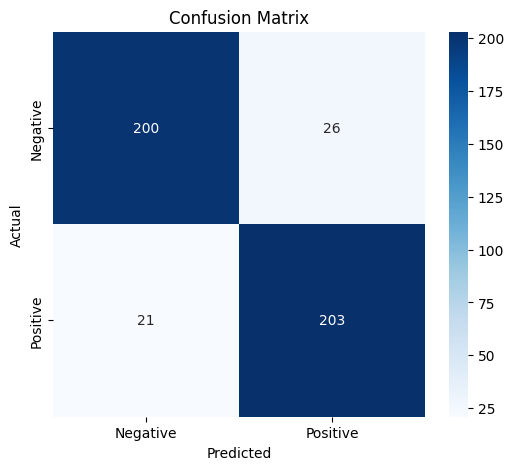

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

STEP 18 — Classification Report

In [ ]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89       226
           1       0.89      0.91      0.90       224

    accuracy                           0.90       450
   macro avg       0.90      0.90      0.90       450
weighted avg       0.90      0.90      0.90       450



In [ ]:
EXPERIMENT 1 — Freeze BERT Layers

In [ ]:
model_frozen = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

# Freeze BERT layers
for param in model_frozen.bert.parameters():
    param.requires_grad = False
trainer_frozen = Trainer(
    model=model_frozen,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics
)
trainer_frozen.train()
frozen_results = trainer_frozen.evaluate(test_dataset)

print(frozen_results)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.696907,0.493333,0.511450,0.290043,0.370166
2,0.699984,0.693318,0.522222,0.526316,0.692641,0.598131


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

{'eval_loss': 0.6965062022209167, 'eval_accuracy': 0.4533333333333333, 'eval_precision': 0.4642857142857143, 'eval_recall': 0.6383928571428571, 'eval_f1': 0.5375939849624061, 'eval_runtime': 7.9196, 'eval_samples_per_second': 56.821, 'eval_steps_per_second': 7.197, 'epoch': 2.0}


EXPERIMENT 2 — Fine-Tune Last 2 BERT Layers

In [ ]:
model_last2 = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)
# Freeze all layers first
for param in model_last2.bert.parameters():
    param.requires_grad = False
# Unfreeze last 2 encoder layers
for param in model_last2.bert.encoder.layer[-2:].parameters():
    param.requires_grad = True
trainer_last2 = Trainer(
    model=model_last2,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics
)
trainer_last2.train()
last2_results = trainer_last2.evaluate(test_dataset)

print(last2_results)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.337246,0.864444,0.837302,0.913420,0.873706
2,0.399928,0.326369,0.875556,0.854251,0.913420,0.882845


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

{'eval_loss': 0.2737587094306946, 'eval_accuracy': 0.8977777777777778, 'eval_precision': 0.908256880733945, 'eval_recall': 0.8839285714285714, 'eval_f1': 0.8959276018099548, 'eval_runtime': 6.5487, 'eval_samples_per_second': 68.716, 'eval_steps_per_second': 8.704, 'epoch': 2.0}


STEP 19 — Compare Experiment Results

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Full Fine-Tuning",
        "Frozen BERT",
        "Last 2 Layers Fine-Tuned"
    ],
    "Accuracy": [
        results['eval_accuracy'],
        frozen_results['eval_accuracy'],
        last2_results['eval_accuracy']
    ],
    "F1 Score": [
        results['eval_f1'],
        frozen_results['eval_f1'],
        last2_results['eval_f1']
    ]
})

comparison

,Model,Accuracy,F1 Score
0,Full Fine-Tuning,0.895556,0.896247
1,Frozen BERT,0.453333,0.537594
2,Last 2 Layers Fine-Tuned,0.897778,0.895928


STEP 20 — Plot Comparison

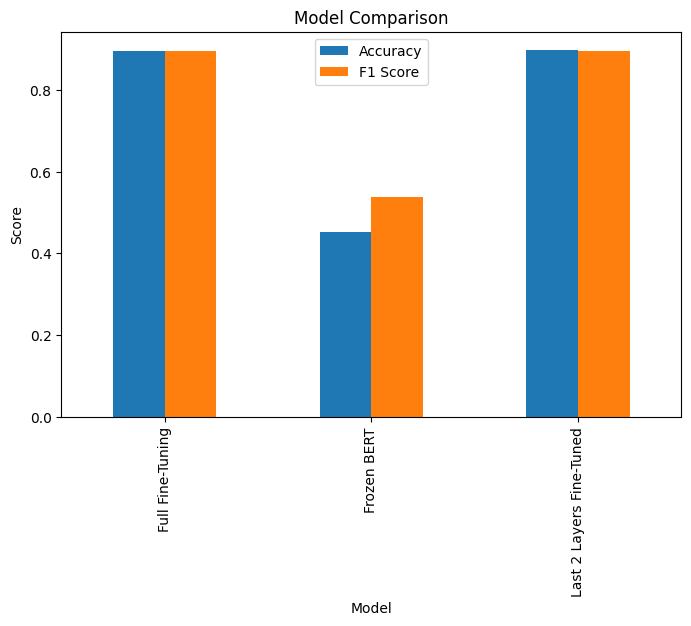

In [ ]:
comparison.plot(
    x='Model',
    y=['Accuracy', 'F1 Score'],
    kind='bar',
    figsize=(8,5)
)

plt.title("Model Comparison")
plt.ylabel("Score")

plt.show()